In [1]:
print('Hello World!')

Hello World!


In [2]:
import time
time.sleep(3)

In [3]:
import numpy as np
def square(x):
    return x * x

In [4]:
x = np.random.randint(1, 10)
y = square(x)
print('%d squared is %d' % (x, y))

7 squared is 49


In [5]:
def selection_sort(arr):
    arr = arr.copy()
    n = len(arr)
    for i in range(n):
        min_index = i
        for j in range(i + 1, n):
            if arr[j] < arr[min_index]:
                min_index = j
        arr[i], arr[min_index] = arr[min_index], arr[i]
    return arr

In [6]:
def test():
    data_input = input("请输入要排序的数字，用空格分隔：")
    data = list(map(int, data_input.split()))
    print("原始数据：", data)
    sorted_data = selection_sort(data)
    print("排序后：", sorted_data)
    
test()

请输入要排序的数字，用空格分隔： 111 22 35 86 5 1 0 69


原始数据： [111, 22, 35, 86, 5, 1, 0, 69]
排序后： [0, 1, 5, 22, 35, 69, 86, 111]


In [7]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv("fortune500.csv")

In [9]:
df.head()

,Year,Rank,Company,Revenue (in millions),Profit (in millions)
0,1955,1,General Motors,9823.5,806
1,1955,2,Exxon Mobil,5661.4,584.8
2,1955,3,U.S. Steel,3250.4,195.4
3,1955,4,General Electric,2959.1,212.6
4,1955,5,Esmark,2510.8,19.1


In [10]:
df.tail()

,Year,Rank,Company,Revenue (in millions),Profit (in millions)
25495,2005,496,Wm. Wrigley Jr.,3648.6,493
25496,2005,497,Peabody Energy,3631.6,175.4
25497,2005,498,Wendy's International,3630.4,57.8
25498,2005,499,Kindred Healthcare,3616.6,70.6
25499,2005,500,Cincinnati Financial,3614.0,584


In [11]:
df.columns = ['year', 'rank', 'company', 'revenue', 'profit']

In [12]:
len(df)

25500

In [13]:
df.dtypes

year         int64
rank         int64
company     object
revenue    float64
profit      object
dtype: object

In [14]:
non_numberic_profits = df.profit.str.contains('[^0-9.-]')
df.loc[non_numberic_profits].head()

,year,rank,company,revenue,profit
228,1955,229,Norton,135.0,N.A.
290,1955,291,Schlitz Brewing,100.0,N.A.
294,1955,295,Pacific Vegetable Oil,97.9,N.A.
296,1955,297,Liebmann Breweries,96.0,N.A.
352,1955,353,Minneapolis-Moline,77.4,N.A.


In [15]:
len(df.profit[non_numberic_profits])

369

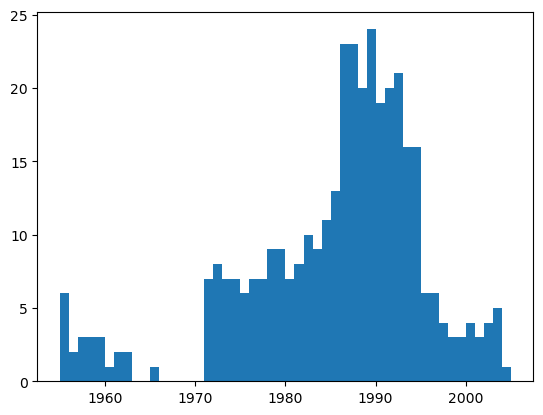

In [16]:
bin_sizes, _, _ = plt.hist(df.year[non_numberic_profits], bins=range(1955, 2006))
plt.show()

In [17]:
df.year[non_numberic_profits]

228      1955
290      1955
294      1955
296      1955
352      1955
         ... 
24242    2003
24296    2003
24435    2003
24489    2003
25485    2005
Name: year, Length: 369, dtype: int64

In [18]:
df = df.loc[~non_numberic_profits]
df.profit = df.profit.apply(pd.to_numeric)

In [19]:
len(df)

25131

In [20]:
df.dtypes

year         int64
rank         int64
company     object
revenue    float64
profit     float64
dtype: object

In [21]:
group_by_year = df.loc[:, ['year', 'revenue', 'profit']].groupby('year')
avgs = group_by_year.mean()
x = avgs.index
y1 = avgs.profit
def plot(x, y, ax, title, y_label):
    ax.set_title(title)
    ax.set_ylabel(y_label)
    ax.plot(x, y)
    ax.margins(x=0, y=0)

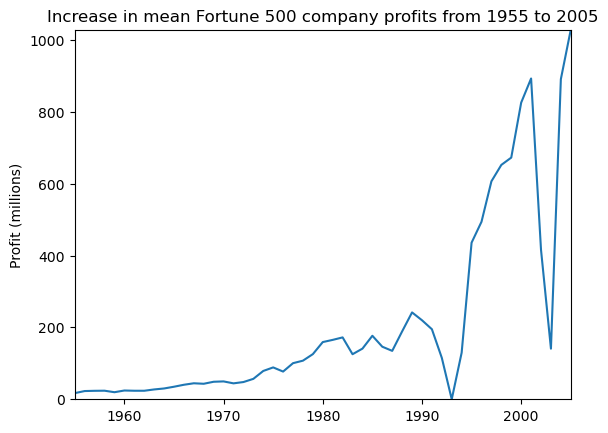

In [22]:
fig, ax = plt.subplots()
plot(x, y1, ax, 'Increase in mean Fortune 500 company profits from 1955 to 2005', 'Profit (millions)')
fig

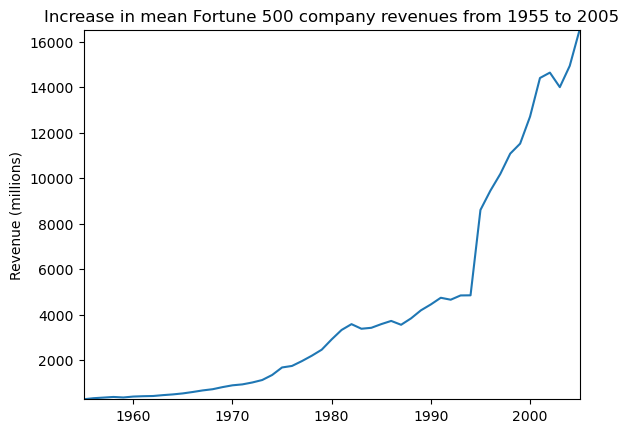

In [23]:
y2 = avgs.revenue
fig, ax = plt.subplots()
plot(x, y2, ax, 'Increase in mean Fortune 500 company revenues from 1955 to 2005', 'Revenue (millions)')
fig

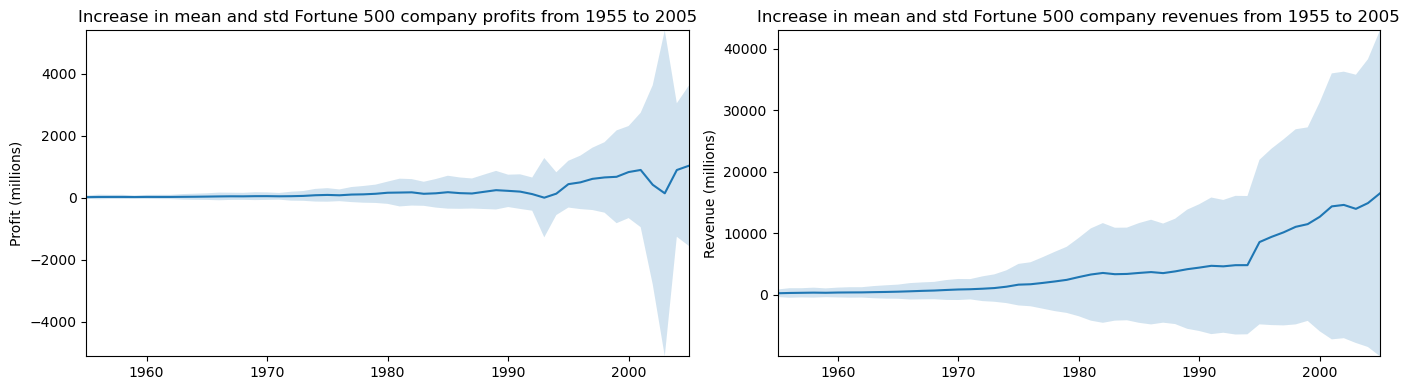

In [24]:
def plot_with_std(x, y, stds, ax, title, y_label):
    ax.fill_between(x, y - stds, y + stds, alpha=0.2)
    plot(x, y, ax, title, y_label)
fig, (ax1, ax2) = plt.subplots(ncols=2)
title = 'Increase in mean and std Fortune 500 company %s from 1955 to 2005'
stds1 = group_by_year.std().profit.values
stds2 = group_by_year.std().revenue.values
plot_with_std(x, y1.values, stds1, ax1, title % 'profits', 'Profit (millions)')
plot_with_std(x, y2.values, stds2, ax2, title % 'revenues', 'Revenue (millions)')
fig.set_size_inches(14, 4)
fig.tight_layout()
fig

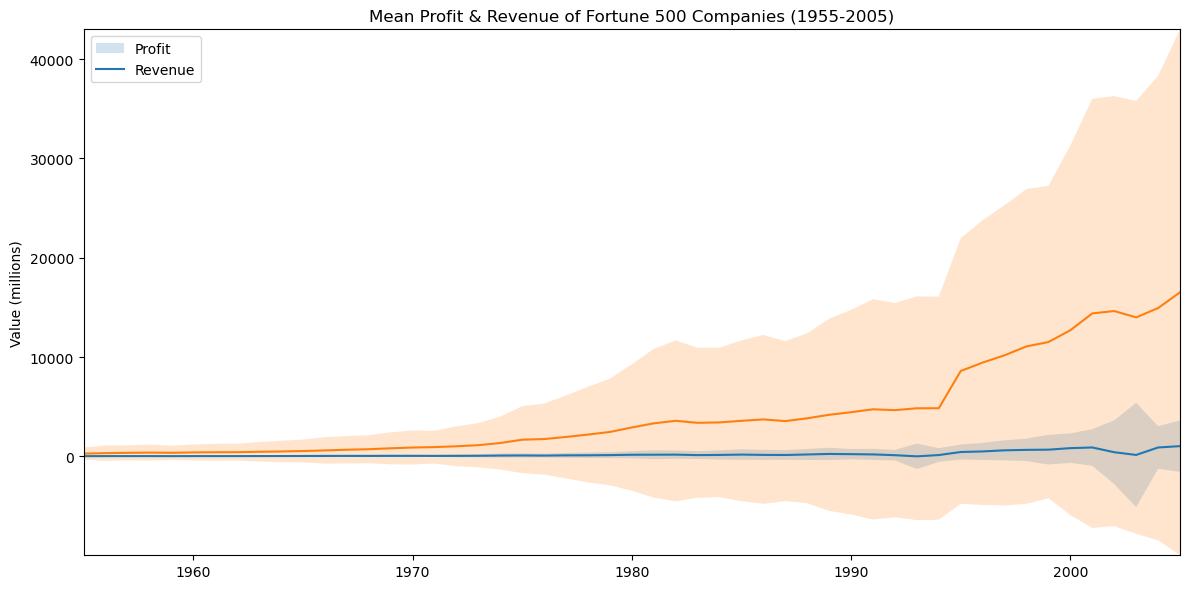

In [25]:
fig, ax = plt.subplots(figsize=(12, 6))
tds1 = group_by_year.std().profit.values
plot_with_std(x, y1.values, stds1, ax, 'Mean Profit & Revenue of Fortune 500 Companies (1955-2005)', 'Value (millions)')
stds2 = group_by_year.std().revenue.values
ax.fill_between(x, y2.values - stds2, y2.values + stds2, alpha=0.2)
ax.plot(x, y2.values, label='Revenue')
ax.legend(['Profit', 'Revenue'])
fig.tight_layout()
fig

In [52]:
import os
# 当前notebook所在绝对路径
print(os.getcwd())

C:\Users\lll88
